Cell 0: Setup (run first in every session)

It re-clones the repo each time, so the "untracked files would be overwritten" pull conflict can't happen again. Nothing in the Colab copy is ever edited, and all outputs go to Drive.

In [32]:
%cd /content
import os, shutil, json
from google.colab import drive
drive.mount('/content/drive')

# 1. Fresh code every session
!rm -rf /content/repo
!git clone -q https://github.com/Maryam-Faatima/genai-restoration-sketch-studio.git /content/repo
%cd /content/repo
!pip install -q -r requirements.txt 2>&1 | tail -1

# 2. Environment
os.environ["DATA_ROOT"] = "/content/data"
os.environ["CKPT_ROOT"] = "/content/drive/MyDrive/genai_a1/checkpoints"
os.makedirs(os.environ["CKPT_ROOT"], exist_ok=True)

# 3. Pet data: local -> copy from Drive -> regenerate (in that order), with checks
LOCAL = "/content/data/pets"
DRIVE = "/content/drive/MyDrive/genai_a1/data/pets"
need = ["trainval.npy", "test.npy", "split.json"]
have = lambda d: all(os.path.exists(f"{d}/{f}") and os.path.getsize(f"{d}/{f}") > 0 for f in need)

if not have(LOCAL):
    if have(DRIVE):
        print("Copying pets from Drive...")
        shutil.copytree(DRIVE, LOCAL, dirs_exist_ok=True)
    else:
        print("Not on Drive: regenerating (a few minutes)...")
        !python -m src.data.prepare_pets
        shutil.copytree(LOCAL, DRIVE, dirs_exist_ok=True)   # back up for next time
assert have(LOCAL), "Pet data is still missing, stop and check"

# 4. The manifests must match this split
split = json.load(open(f"{LOCAL}/split.json"))
vm = json.load(open("manifests/val_manifest.json"))
assert sorted(e["img_idx"] for e in vm) == sorted(split["val"]), "val manifest does not match split!"
print("Pet data OK, manifests match.")

# 5. Tracking + GPU
import wandb
wandb.login()
!nvidia-smi --query-gpu=name --format=csv,noheader

/content
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/repo
Pet data OK, manifests match.
Tesla T4


Cell 1: Pull new code (optional)

Use this when you've pushed changes mid-session and don't want to re-run Cell 0.

In [ ]:
%cd /content/repo
!git pull

/content/repo
Already up to date.


#Task 1

In [ ]:
# 1a. timed 5-epoch check
%%time
!python -m src.training.train_ae --epochs 5 --no_wandb --run_name smoke5

config: {'lr': 0.001, 'batch_size': 32, 'base': 32, 'bottleneck': 256, 'dropout': 0.1, 'alpha': 0.8}
ep   0 | loss 0.3179 | score 0.2994 | SSIM 0.296 PSNR 12.10
ep   1 | loss 0.2857 | score 0.3126 | SSIM 0.306 PSNR 12.76
ep   2 | loss 0.2481 | score 0.3506 | SSIM 0.335 PSNR 14.63
ep   3 | loss 0.2400 | score 0.3669 | SSIM 0.348 PSNR 15.44
ep   4 | loss 0.2355 | score 0.3715 | SSIM 0.354 PSNR 15.56
best score: 0.3715125352144241
CPU times: user 109 ms, sys: 20.7 ms, total: 130 ms
Wall time: 1min 5s


In [ ]:
# 1b. Optuna study (resumable; the DB syncs to Drive after every trial)
!python -m src.training.optuna_ae --n_trials 20 --epochs 8

[I 2026-10-03 09:31:15,982] A new study created in RDB with name: task1_ae_v2
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run dgp9v522 (0.3s)
wandb: ⣯ setting up run dgp9v522 (0.3s)
wandb: ⣟ setting up run dgp9v522 (0.3s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_093117-dgp9v522
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run t1-trial0
wandb: ⭐️ View project at https://wandb.ai/i230788

In [ ]:
# 1c. final training with the best config
!python -m src.training.train_ae --config configs/task1_best.json --epochs 60 --run_name task1-final


config: {'lr': 0.00011577359897920416, 'batch_size': 16, 'base': 64, 'bottleneck': 512, 'dropout': 0.30000000000000004, 'alpha': 0.55}
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run mntgli7e (0.2s)
wandb: ⣯ setting up run mntgli7e (0.2s)
wandb: ⣟ setting up run mntgli7e (0.2s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261002_141501-mntgli7e
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run tas

Task 1 v2 bottleneck


In [ ]:
%%time
!python -m src.training.train_ae --epochs 5 --no_wandb --run_name smoke5-v2

config: {'lr': 0.001, 'batch_size': 32, 'base': 32, 'latent_ch': 16, 'dropout': 0.1, 'alpha': 0.8}
ep   0 | loss 0.2323 | score 0.4268 | SSIM 0.428 PSNR 17.01
ep   1 | loss 0.1865 | score 0.4717 | SSIM 0.486 PSNR 18.29
ep   2 | loss 0.1733 | score 0.4800 | SSIM 0.496 PSNR 18.56
ep   3 | loss 0.1679 | score 0.4678 | SSIM 0.493 PSNR 17.71
ep   4 | loss 0.1631 | score 0.5037 | SSIM 0.524 PSNR 19.34
best score: 0.5036985516548157
CPU times: user 127 ms, sys: 17 ms, total: 144 ms
Wall time: 1min 12s


In [ ]:
import os
cfg = f"{os.environ['CKPT_ROOT']}/task1/task1_v2_best.json"
!python -m src.training.train_ae --config {cfg} --epochs 40 --run_name task1-v2-final

config: {'lr': 0.0001408583749753797, 'batch_size': 16, 'base': 48, 'latent_ch': 32, 'dropout': 0.4, 'alpha': 0.55}
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run h00qbkyx (0.3s)
wandb: ⣯ setting up run h00qbkyx (0.3s)
wandb: ⣟ setting up run h00qbkyx (0.3s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_100014-h00qbkyx
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run task1-v2-final
wandb: ⭐️ View project at https://wandb.ai/i230788-fast-nu

In [ ]:
!python -m src.training.optuna_spec --n_trials 8 --epochs 6

[I 2026-10-03 10:14:00,733] A new study created in RDB with name: task2_spec_v2
t2spec-trial0: train types [1, 2, 3] | val images 552
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run sk4lkvkh (0.3s)
wandb: ⣯ setting up run sk4lkvkh (0.3s)
wandb: ⣟ setting up run sk4lkvkh (0.3s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_101402-sk4lkvkh
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run t2spec-trial0
wandb: ⭐️ View project at https://wandb.ai/i230788-fast-nuces/genai-a1-restoration
wandb: 🚀 View run at htt

In [ ]:
import os
cfg = f"{os.environ['CKPT_ROOT']}/task2/task2_spec_v2_best.json"
!python -m src.training.train_spec --config {cfg} --which all --epochs 30

config: {'lr': 0.0003071057367777374, 'batch_size': 16, 'base': 64, 'latent_ch': 32, 'dropout': 0.1, 'alpha': 0.9}
task2-spec-salt: train types [1] | val images 184
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run 36z4css9 (0.3s)
wandb: ⣯ setting up run 36z4css9 (0.3s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_102335-36z4css9
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run task2-spec-salt
wandb: ⭐️ View project at https://wandb.ai/i230788-fast-nuces/genai-a1-restoration
wandb: 🚀 View run at https://wandb.ai/i230788-fast-nuces/genai-a1-restoration/runs

In [ ]:
!python -m scripts.eval_task1
!python -m scripts.eval_task2

config: {'lr': 0.0001408583749753797, 'batch_size': 16, 'base': 48, 'latent_ch': 32, 'dropout': 0.4, 'alpha': 0.55}

group                           n  in_PSNR  out_PSNR  in_SSIM  out_SSIM      L1
overall                     36690    22.34     20.52    0.671     0.639  0.0725
clean                        3669    50.00     21.21    1.000     0.677  0.0676
salt_pepper                 11007    16.38     21.03    0.382     0.651  0.0691
salt_pepper/low              3669    20.14     21.17    0.603     0.669  0.0680
salt_pepper/medium           3669    15.87     21.05    0.339     0.652  0.0689
salt_pepper/high             3669    13.14     20.86    0.204     0.632  0.0704
blur                        11007    27.82     21.04    0.814     0.653  0.0692
blur/low                     3669    32.34     21.23    0.944     0.674  0.0675
blur/medium                  3669    26.77     21.12    0.806     0.659  0.0686
blur/high                    3669    24.35     20.77    0.692     0.624  0.0715
occ

Graphing and all


/content/repo


/tmp/ipykernel_1357/354270439.py:11: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(s)


saved history


/tmp/ipykernel_1357/354270439.py:11: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(s)


saved importance


/tmp/ipykernel_1357/354270439.py:11: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(s)


saved parallel
best trial number: 18


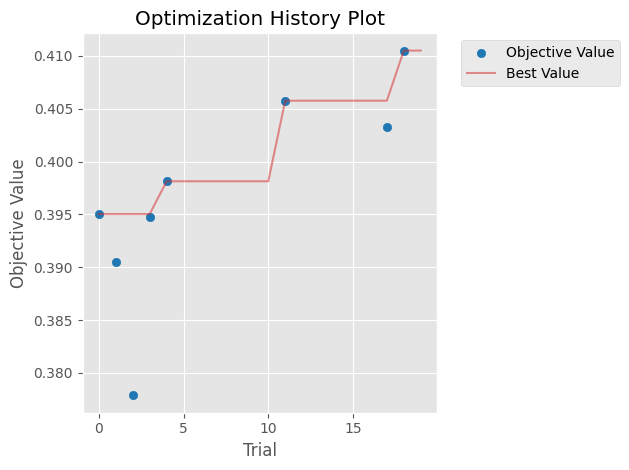

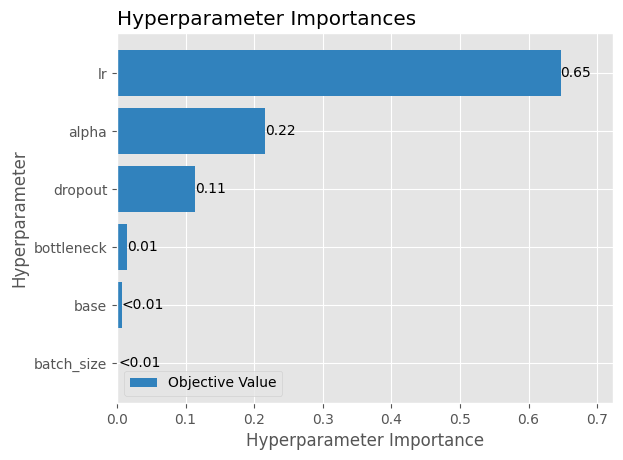

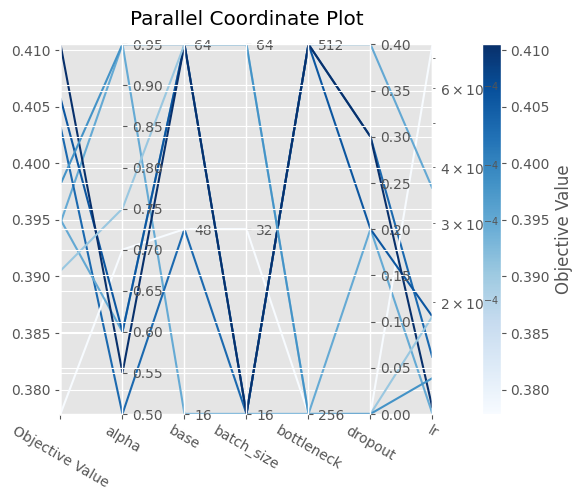

In [ ]:
import optuna, matplotlib
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances, plot_parallel_coordinate
%cd /content/repo
s = optuna.load_study(study_name="task1_ae", storage="sqlite:///studies/task1_ae.db")
os_dir = "/content/drive/MyDrive/genai_a1/checkpoints/task1/optuna_figs"
import os; os.makedirs(os_dir, exist_ok=True)
for name, fn in [("history", plot_optimization_history), ("importance", plot_param_importances),
                 ("parallel", plot_parallel_coordinate)]:
    try:
        ax = fn(s)
        fig = ax.figure if hasattr(ax, "figure") else plt.gcf()
        fig.savefig(f"{os_dir}/{name}.png", dpi=150, bbox_inches="tight")
        print("saved", name)
    except Exception as e:
        print(name, "failed:", e)
print("best trial number:", s.best_trial.number)

In [ ]:
!python -m scripts.eval_task1

config: {'lr': 0.00011577359897920416, 'batch_size': 16, 'base': 64, 'bottleneck': 512, 'dropout': 0.30000000000000004, 'alpha': 0.55}

group                           n  in_PSNR  out_PSNR  in_SSIM  out_SSIM      L1
overall                     36690    22.34     17.85    0.671     0.439  0.0957
clean                        3669    50.00     18.02    1.000     0.446  0.0937
salt_pepper                 11007    16.38     18.04    0.382     0.444  0.0937
salt_pepper/low              3669    20.14     18.05    0.603     0.446  0.0935
salt_pepper/medium           3669    15.87     18.05    0.339     0.444  0.0936
salt_pepper/high             3669    13.14     18.03    0.204     0.442  0.0941
blur                        11007    27.82     18.08    0.814     0.444  0.0936
blur/low                     3669    32.34     18.05    0.944     0.446  0.0935
blur/medium                  3669    26.77     18.09    0.806     0.445  0.0936
blur/high                    3669    24.35     18.11    0.692   

##After v2 making it better (v3)

In [ ]:
base = "/content/drive/MyDrive/genai_a1/checkpoints"
!cp -r {base}/task1 {base}/task1_v2
!cp -r {base}/task2 {base}/task2_v2

In [ ]:
%cd /content/repo
import torch
from src.models.autoencoder import build_ae
for cfg in [dict(base=48, latent_ch=32), dict(base=48, latent_ch=32, skip_ch=4),
            dict(base=48, latent_ch=64, skip_ch=8)]:
    m = build_ae(cfg); y = m(torch.randn(2, 3, 128, 128))
    print(cfg, tuple(y.shape), sum(p.numel() for p in m.parameters()))
ck = torch.load(f"{base}/task1_v2/best.pt", map_location="cpu")   # old checkpoint must still load
build_ae(ck["cfg"]).load_state_dict(ck["state_dict"]); print("v2 checkpoint loads OK")

/content/repo
{'base': 48, 'latent_ch': 32} (2, 3, 128, 128) 3918195
{'base': 48, 'latent_ch': 32, 'skip_ch': 4} (2, 3, 128, 128) 3925111
{'base': 48, 'latent_ch': 64, 'skip_ch': 8} (2, 3, 128, 128) 4013979
v2 checkpoint loads OK


In [ ]:
import json, os, subprocess
common = dict(lr=5e-4, batch_size=32, base=48, dropout=0.1, alpha=0.6)
runs = {"A_lat32_noskip": dict(latent_ch=32, skip_ch=0), "B_lat64_noskip": dict(latent_ch=64, skip_ch=0),
        "C_lat32_skip4": dict(latent_ch=32, skip_ch=4),  "D_lat32_skip8": dict(latent_ch=32, skip_ch=8)}
for name, extra in runs.items():
    p = f"/content/cfg_{name}.json"; json.dump({**common, **extra}, open(p, "w"))
    env = {**os.environ, "CKPT_ROOT": f"/content/abl/{name}"}
    r = subprocess.run(["python", "-m", "src.training.train_ae", "--config", p, "--epochs", "15",
                        "--no_wandb", "--run_name", name], env=env, capture_output=True, text=True, cwd="/content/repo")
    print(name, "->", r.stdout.strip().splitlines()[-2:])

A_lat32_noskip -> ['ep  14 | loss 0.1916 | score 0.5754 | SSIM 0.636 PSNR 20.57', 'best score: 0.5753838002681733']
B_lat64_noskip -> ['ep  14 | loss 0.1942 | score 0.5687 | SSIM 0.626 PSNR 20.45', 'best score: 0.5687448501586914']
C_lat32_skip4 -> ['ep  14 | loss 0.1760 | score 0.6058 | SSIM 0.684 PSNR 21.12', 'best score: 0.6058053791522979']
D_lat32_skip8 -> ['ep  14 | loss 0.1702 | score 0.6104 | SSIM 0.691 PSNR 21.20', 'best score: 0.6104420483112335']


In [ ]:
!python -m src.training.optuna_ae --n_trials 24 --epochs 12

[I 2026-10-03 12:09:41,309] A new study created in RDB with name: task1_ae_v3
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run tvrx29pe (0.2s)
wandb: ⣯ setting up run tvrx29pe (0.2s)
wandb: ⣟ setting up run tvrx29pe (0.2s)
wandb: ⡿ setting up run tvrx29pe (0.2s)
wandb: ⢿ setting up run tvrx29pe (0.2s)
wandb: ⣻ setting up run tvrx29pe (0.7s)
wandb: ⣽ setting up run tvrx29pe (0.7s)
wandb: ⣾ setting up run tvrx29pe (0.7s)
wandb: ⣷ setting up run tvrx29pe (0.7s)
wandb: ⣯ setting u

In [ ]:
import os
cfg = f"{os.environ['CKPT_ROOT']}/task1/task1_v3_best.json"
!python -m src.training.train_ae --config {cfg} --epochs 100 --run_name task1-v3-final

config: {'lr': 0.0004549902457423108, 'batch_size': 32, 'base': 32, 'latent_ch': 64, 'dropout': 0.1, 'alpha': 0.6, 'skip_ch': 4}
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run rolihjz8 (0.3s)
wandb: ⣯ setting up run rolihjz8 (0.3s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_125137-rolihjz8
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run task1-v3-final
wandb: ⭐️ View project at https://

In [ ]:
!python -m src.training.optuna_spec --n_trials 12 --epochs 8

[I 2026-10-03 13:09:37,528] A new study created in RDB with name: task2_spec_v3
t2spec-trial0: train types [1, 2, 3] | val images 552
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run 61iv8597 (0.3s)
wandb: ⣯ setting up run 61iv8597 (0.3s)
wandb: ⣟ setting up run 61iv8597 (0.3s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_130938-61iv8597
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run t2spec-trial0
wandb: ⭐️ View project at https://wandb.ai/i230788-fast-nuces/genai-a1-restoration
wandb: 🚀 View run at htt

In [ ]:
import os
cfg = f"{os.environ['CKPT_ROOT']}/task2/task2_spec_v3_best.json"
!python -m src.training.train_spec --config {cfg} --which all --epochs 60

config: {'lr': 0.0009024740059313989, 'batch_size': 16, 'base': 32, 'latent_ch': 48, 'dropout': 0.1, 'alpha': 0.6, 'skip_ch': 8}
task2-spec-salt: train types [1] | val images 184
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run 1ninih41 (0.2s)
wandb: ⣯ setting up run 1ninih41 (0.2s)
wandb: ⣟ setting up run 1ninih41 (0.2s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_132829-1ninih41
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run task2-spec-salt
wandb: ⭐️ View project at https://wandb.ai/i230788-fast-nuce

In [ ]:
import json, os
c = json.load(open(f"{os.environ['CKPT_ROOT']}/task1/task1_v3_best.json")); c["skip_ch"] = 0
json.dump(c, open("/content/cfg_noskip.json", "w"))
!CKPT_ROOT=/content/drive/MyDrive/genai_a1/ablation_noskip python -m src.training.train_ae --config /content/cfg_noskip.json --epochs 100 --run_name task1-v3-noskip

config: {'lr': 0.0004549902457423108, 'batch_size': 32, 'base': 32, 'latent_ch': 64, 'dropout': 0.1, 'alpha': 0.6, 'skip_ch': 0}
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run tllqvvxk (0.3s)
wandb: ⣯ setting up run tllqvvxk (0.3s)
wandb: ⣟ setting up run tllqvvxk (0.3s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_140139-tllqvvxk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run task1-v3-noskip
wandb: ⭐️ View project at https://wandb.ai/i

In [ ]:
import os, shutil, json, torch
base = os.environ["CKPT_ROOT"]
t1 = f"{base}/task1"
abl = "/content/drive/MyDrive/genai_a1/ablation_noskip/task1"
print("ablation folder:", os.listdir(abl))

cur = torch.load(f"{t1}/best.pt", map_location="cpu")
new = torch.load(f"{abl}/best.pt", map_location="cpu")
print("current task1/best.pt skip_ch:", cur["cfg"].get("skip_ch"), "| score", round(cur["score"], 4))
print("ablation no-skip   skip_ch:", new["cfg"].get("skip_ch"), "| score", round(new["score"], 4))

if cur["cfg"].get("skip_ch", 0) > 0 and not os.path.exists(f"{t1}/best_skip4.pt"):
    shutil.copy(f"{t1}/best.pt", f"{t1}/best_skip4.pt")          # keep the skip model
    shutil.copy(f"{abl}/best.pt", f"{t1}/best.pt")               # no-skip becomes final
    print("done: no-skip is now task1/best.pt, skip model saved as best_skip4.pt")
if os.path.exists(f"{t1}/eval") and not os.path.exists(f"{t1}/eval_old"):
    shutil.move(f"{t1}/eval", f"{t1}/eval_old")                   # nothing gets overwritten

c = json.load(open(f"{t1}/task1_v3_best.json")); c["skip_ch"] = 0
json.dump(c, open(f"{t1}/task1_final_best.json", "w"), indent=2)
print("final config:", c)

ablation folder: ['best.pt', 'val_summary.json']
current task1/best.pt skip_ch: 4 | score 0.6392
ablation no-skip   skip_ch: 0 | score 0.6462
done: no-skip is now task1/best.pt, skip model saved as best_skip4.pt
final config: {'lr': 0.0004549902457423108, 'batch_size': 32, 'latent_ch': 64, 'base': 32, 'dropout': 0.1, 'alpha': 0.6, 'skip_ch': 0}


In [ ]:
%cd /content/repo
!python -m scripts.eval_task1

/content/repo
config: {'lr': 0.0004549902457423108, 'batch_size': 32, 'base': 32, 'latent_ch': 64, 'dropout': 0.1, 'alpha': 0.6, 'skip_ch': 0}

group                           n  in_PSNR  out_PSNR  in_SSIM  out_SSIM      L1
overall                     36690    22.34     21.63    0.671     0.735  0.0629
clean                        3669    50.00     22.45    1.000     0.775  0.0583
salt_pepper                 11007    16.38     22.34    0.382     0.760  0.0591
salt_pepper/low              3669    20.14     22.44    0.603     0.771  0.0584
salt_pepper/medium           3669    15.87     22.37    0.339     0.762  0.0589
salt_pepper/high             3669    13.14     22.20    0.204     0.745  0.0600
blur                        11007    27.82     22.33    0.814     0.753  0.0592
blur/low                     3669    32.34     22.54    0.944     0.774  0.0579
blur/medium                  3669    26.77     22.49    0.806     0.765  0.0583
blur/high                    3669    24.35     21.97    

In [ ]:
import os, shutil, torch
t2 = f"{os.environ['CKPT_ROOT']}/task2"
print("specialist config:", torch.load(f"{t2}/spec_blur.pt", map_location="cpu")["cfg"])
if os.path.exists(f"{t2}/eval") and not os.path.exists(f"{t2}/eval_old"):
    shutil.move(f"{t2}/eval", f"{t2}/eval_old")
%cd /content/repo
!python -m scripts.eval_task2

specialist config: {'lr': 0.0009024740059313989, 'batch_size': 16, 'base': 32, 'latent_ch': 48, 'dropout': 0.1, 'alpha': 0.6, 'skip_ch': 8}
/content/repo
group                         n  inPSNR  oraPSNR  prdPSNR  inSSIM  oraSSIM  prdSSIM  clsAcc
overall                   36690   22.34    26.60    26.56   0.671    0.804    0.804   0.998
clean                      3669   50.00    50.00    49.63   1.000    1.000    0.997   0.985
salt_pepper               11007   16.38    25.57    25.57   0.382    0.827    0.827   1.000
salt_pepper/low            3669   20.14    25.63    25.63   0.603    0.831    0.831   1.000
salt_pepper/medium         3669   15.87    25.59    25.59   0.339    0.828    0.828   1.000
salt_pepper/high           3669   13.14    25.47    25.47   0.204    0.822    0.822   1.000
blur                      11007   27.82    25.36    25.36   0.814    0.803    0.803   1.000
blur/low                   3669   32.34    25.69    25.69   0.944    0.828    0.828   1.000
blur/medium       

#TASK 2

In [ ]:
# 2a. smoke test (about 30 s). Check "first batch class counts" prints [8, 8, 8, 8]
!python -m src.training.train_cls --epochs 2 --no_wandb --run_name smoke-cls

config: {'lr': 0.001, 'batch_size': 32, 'channels': 'medium', 'dropout': 0.3, 'weight_decay': 0.0001}
first batch class counts [clean, salt, blur, occ]: [8, 8, 8, 8]
ep   0 | loss 0.1816 train acc 0.934 | val acc 0.978 macro-F1 0.978
ep   1 | loss 0.0583 train acc 0.982 | val acc 0.984 macro-F1 0.984
best macro-F1: 0.98374499288489


In [ ]:
# 2b. classifier Optuna
!python -m src.training.optuna_cls --n_trials 15 --epochs 10

[I 2026-10-02 15:07:56,840] Using an existing study with `study_name='task2_cls'` instead of creating a new one.
first batch class counts [clean, salt, blur, occ]: [4, 4, 4, 4]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ Waiting for wandb.init()...
wandb: ⣯ Waiting for wandb.init()...
wandb: ⣟ Waiting for wandb.init()...
wandb: ⡿ Waiting for wandb.init()...
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run ol64je5u (0.1s)
wandb: ⣽ setting up run ol64je5u (0.1s)
wandb: ⣾ setting up run ol64je5u (0.1s)
wandb: ⣷ setting up run ol64je5u (0.1s)
wandb: ⣯ setting up run ol64je5u (0.1s)
wandb: ⣟ se

In [ ]:
# 2c. final classifier
!python -m src.training.train_cls --config configs/task2_cls_best.json --epochs 40 --run_name task2-cls-final

config: {'lr': 0.0007106591851092234, 'batch_size': 16, 'channels': 'small', 'dropout': 0.5, 'weight_decay': 0.00025378155082656634}
first batch class counts [clean, salt, blur, occ]: [4, 4, 4, 4]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run kwr2mheb (0.2s)
wandb: ⣯ setting up run kwr2mheb (0.2s)
wandb: ⣟ setting up run kwr2mheb (0.2s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261002_151835-kwr2mheb
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run task2-cls-final
wandb: ⭐️ View project at https://wandb.ai

In [ ]:
# 2d. shared specialist search
!python -m src.training.optuna_spec --n_trials 12 --epochs 6

[I 2026-10-02 15:22:48,053] Using an existing study with `study_name='task2_spec'` instead of creating a new one.
t2spec-trial1: train types [1, 2, 3] | val images 552
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ Waiting for wandb.init()...
wandb: ⣯ setting up run 60wrcnbj (0.3s)
wandb: ⣟ setting up run 60wrcnbj (0.3s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261002_152249-60wrcnbj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run t2spec-trial1
wandb: ⭐️ View project at https://wandb.ai/i230788-fast-nuces/genai-a1-resto

In [ ]:
# 2e. three independent specialists (salt, blur, occ), one after another
!python -m src.training.train_spec --config configs/task2_spec_best.json --which all --epochs 40

config: {'lr': 0.0003071057367777374, 'batch_size': 16, 'base': 64, 'bottleneck': 256, 'dropout': 0.1, 'alpha': 0.95}
task2-spec-salt: train types [1] | val images 184
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run q14fde66 (0.3s)
wandb: ⣯ setting up run q14fde66 (0.3s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261002_155113-q14fde66
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run task2-spec-salt
wandb: ⭐️ View project at https://wandb.ai/i230788-fast-nuces/genai-a1-restoration
wandb: 🚀 View run at https:/

In [ ]:
# 2f. evaluation on the official test set, once, at the end
!python -m scripts.eval_task2

group                         n  inPSNR  oraPSNR  prdPSNR  inSSIM  oraSSIM  prdSSIM  clsAcc
overall                   36690   22.34    20.71    20.67   0.671    0.468    0.467   0.998
clean                      3669   50.00    50.00    49.51   1.000    1.000    0.992   0.985
salt_pepper               11007   16.38    17.63    17.63   0.382    0.414    0.414   1.000
salt_pepper/low            3669   20.14    17.62    17.62   0.603    0.414    0.414   1.000
salt_pepper/medium         3669   15.87    17.63    17.63   0.339    0.414    0.414   1.000
salt_pepper/high           3669   13.14    17.63    17.63   0.204    0.413    0.413   1.000
blur                      11007   27.82    17.63    17.63   0.814    0.412    0.412   1.000
blur/low                   3669   32.34    17.60    17.60   0.944    0.413    0.413   1.000
blur/medium                3669   26.77    17.64    17.64   0.806    0.412    0.412   1.000
blur/high                  3669   24.35    17.66    17.66   0.692    0.411    0.

#TASK 3

In [ ]:
# 3a. check that the Task 2 parts exist (the v3 specialists plus the classifier)
import os
t2 = f"{os.environ['CKPT_ROOT']}/task2"
print(sorted(f for f in os.listdir(t2) if f.endswith(".pt")))

['classifier.pt', 'spec_blur.pt', 'spec_occ.pt', 'spec_salt.pt']


In [ ]:
# 3b. smoke test: 1 warm-up epoch + 1 joint epoch. Note the time per epoch
%%time
%cd /content/repo
!python -m src.training.train_moe --warm_epochs 1 --joint_epochs 1 --no_wandb --run_name smoke-moe

/content/repo
config: {'lr_joint': 5e-05, 'T': 1.0, 'lam_cls': 0.1, 'lam_bal': 0.01, 'alpha': 0.8, 'batch_size': 32}
ep   0 warm  | loss 0.0598 ce 0.014 bal 0.0002 | val score 0.8023 SSIM 0.840 PSNR 30.60 | gate acc 0.995 | mean w [id 0.24 salt 0.25 blur 0.26 occ 0.25]
ep   1 joint | loss 0.0657 ce 0.013 bal 0.0002 | val score 0.7967 SSIM 0.833 PSNR 30.43 | gate acc 0.997 | mean w [id 0.25 salt 0.25 blur 0.25 occ 0.25]
best score: 0.8022731721401215
CPU times: user 101 ms, sys: 12.8 ms, total: 114 ms
Wall time: 1min 6s


In [ ]:
# 3c. Optuna (resumable, like the others)
!python -m src.training.optuna_moe --n_trials 10 --warm_epochs 1 --joint_epochs 4

[I 2026-10-03 15:25:27,031] A new study created in RDB with name: task3_moe
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_152528-tv6jz6ow
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run t3-trial0
wandb: ⭐️ View project at https://wandb.ai/i230788-fast-nuces/genai-a1-restoration
wandb: 🚀 View run at https://wandb.ai/i230788-fast-nuces/genai-a1-restoration/runs/tv6jz6ow
ep   0 warm  | loss 0.0973 ce 0.032 bal 0.0003 | val score 0.7990 SSIM 0.840 PSNR 30.33 | gate acc 0.993 | mean w [id 0.24 salt 0.25 blur 0.26 occ 0.25]
ep   1 joint

In [ ]:
# 3d. final training with the best config
import os
cfg = f"{os.environ['CKPT_ROOT']}/task3/task3_best.json"
!python -m src.training.train_moe --config {cfg} --warm_epochs 3 --joint_epochs 20 --run_name task3-final

config: {'lr_joint': 0.00011265466963346021, 'T': 1.2615344229334267, 'lam_cls': 0.015679933916723017, 'lam_bal': 0.07026263205443048, 'alpha': 0.7, 'batch_size': 32}
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_154912-mytqgent
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run task3-final
wandb: ⭐️ View project at https://wandb.ai/i230788-fast-nuces/genai-a1-restoration
wandb: 🚀 View run at https://wandb.ai/i230788-fast-nuces/genai-a1-restoration/runs/mytqgent
ep   0 warm  | loss 0.0712 ce 0.069 bal 0.0034 | val score

In [ ]:
# 3e. test evaluation, once, at the end
%cd /content/repo
!python -m scripts.eval_task3

/content/repo
config: {'lr_joint': 0.00011265466963346021, 'T': 1.2615344229334267, 'lam_cls': 0.015679933916723017, 'lam_bal': 0.07026263205443048, 'alpha': 0.7, 'batch_size': 32} | best epoch 16 | val score 0.8164

group                       n  inPSNR  hardPSNR  softPSNR  inSSIM  hardSSIM  softSSIM
overall                 36690   22.34     26.56     26.91   0.671     0.804     0.828
clean                    3669   50.00     49.63     49.74   1.000     0.997     0.999
salt_pepper             11007   16.38     25.57     25.25   0.382     0.827     0.829
salt_pepper/low          3669   20.14     25.63     25.51   0.603     0.831     0.840
salt_pepper/medium       3669   15.87     25.59     25.16   0.339     0.828     0.827
salt_pepper/high         3669   13.14     25.47     25.07   0.204     0.822     0.820
blur                    11007   27.82     25.36     26.89   0.814     0.803     0.831
blur/low                 3669   32.34     25.69     29.18   0.944     0.828     0.905
blur/medi

#TASK 4

In [33]:
# 4a. copy the FS2K cache from Drive, with checks
import os, shutil
LOCAL = "/content/data/fs2k"; DRIVE = "/content/drive/MyDrive/genai_a1/data/fs2k"
need = ["train_photo.npy", "train_sketch.npy", "train_style.npy",
        "test_photo.npy", "test_sketch.npy", "test_style.npy", "split.json"]
ok = lambda d: all(os.path.exists(f"{d}/{f}") and os.path.getsize(f"{d}/{f}") > 0 for f in need)
if not ok(LOCAL):
    assert ok(DRIVE), "FS2K cache missing or empty on Drive: upload data/fs2k from Windows"
    shutil.copytree(DRIVE, LOCAL, dirs_exist_ok=True)
print(sorted(os.listdir(LOCAL)))

['split.json', 'test_photo.npy', 'test_sketch.npy', 'test_style.npy', 'train_photo.npy', 'train_sketch.npy', 'train_style.npy']


In [ ]:
# 4b. smoke test: 2 epochs. Check the printed time per epoch
%%time
!python -m src.training.train_gan --epochs 2 --no_wandb --run_name smoke-gan

config: {'lr_g': 0.0002, 'lr_d': 0.0002, 'batch_size': 16, 'base': 64, 'dropout': 0.3, 'emb_dim': 16, 'lambda_l1': 100.0}
train 899 | val 159
ep   0 | D real 0.789 fake 0.776 | G adv 0.826 L1 0.3291 | val L1 0.1169 PSNR 15.30 SSIM 0.419 style-sens 0.1222
ep   1 | D real 0.646 fake 0.609 | G adv 0.946 L1 0.2291 | val L1 0.1086 PSNR 15.53 SSIM 0.455 style-sens 0.1156
best val SSIM: 0.45489656925201416
CPU times: user 18 ms, sys: 32.2 ms, total: 50.2 ms
Wall time: 27.8 s


In [ ]:
# 4c. Optuna (12 trials, 15 epochs each; resumable like the others)
!python -m src.training.optuna_gan --n_trials 12 --epochs 15

[I 2026-10-03 11:02:04,530] A new study created in RDB with name: task4_gan
train 899 | val 159
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run 76ks0nig (0.2s)
wandb: ⣯ setting up run 76ks0nig (0.2s)
wandb: ⣟ setting up run 76ks0nig (0.2s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_110206-76ks0nig
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run t4-trial0
wandb: ⭐️ View project at https://wandb.ai/i230788-fast-nuces/genai-a1-restoration
wandb: 🚀 View run at https://wandb.ai/i230788-fast-nuces/genai-a1-

In [ ]:
# 4d. final training with the best config (measure the epoch time in 4b first)
import os
cfg = f"{os.environ['CKPT_ROOT']}/task4/task4_best.json"
!python -m src.training.train_gan --config {cfg} --epochs 100 --run_name task4-final

config: {'lr_g': 0.0005958443469672521, 'lr_d': 0.000434979656425666, 'batch_size': 32, 'base': 48, 'dropout': 0.1, 'emb_dim': 32, 'lambda_l1': 200}
train 899 | val 159
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run xt6as9i3 (0.3s)
wandb: ⣯ setting up run xt6as9i3 (0.3s)
wandb: ⣟ setting up run xt6as9i3 (0.3s)
wandb: ⡿ setting up run xt6as9i3 (0.3s)
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_112145-xt6as9i3
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run task4-final
wandb: ⭐️ View project at https://wandb.ai/i230788-fast-nuces/genai-a1-restoration
wa

In [ ]:
# 4e. evaluation on the official test set, once
!python -m scripts.eval_task4

config: {'lr_g': 0.0005958443469672521, 'lr_d': 0.000434979656425666, 'batch_size': 32, 'base': 48, 'dropout': 0.1, 'emb_dim': 32, 'lambda_l1': 200}

group          n       L1     PSNR     SSIM
overall     1046   0.1093    15.27    0.486
style 1      619   0.0851    16.84    0.534
style 2      381   0.1533    12.38    0.394
style 3       46   0.0705    18.01    0.597

style sensitivity (mean |diff| between styles, same photo): 0.1017
true-style output is closest to the target sketch in 81.1% of images (chance = 33.3%)
failure cases (index, style, SSIM): [(221, 2, 0.165), (517, 1, 0.195), (65, 2, 0.204), (42, 2, 0.207)]
saved to /content/drive/MyDrive/genai_a1/checkpoints/task4/eval


In [ ]:
import json, os, shutil, numpy as np, torch
from pytorch_msssim import ssim
d = "/content/data/fs2k"
if not os.path.exists(f"{d}/split.json"):
    shutil.copytree("/content/drive/MyDrive/genai_a1/data/fs2k", d, dirs_exist_ok=True)
sp = json.load(open(f"{d}/split.json"))["train"]
trS = np.load(f"{d}/train_sketch.npy")[sp][..., 0].astype("float32") / 255
trSt = np.load(f"{d}/train_style.npy")[sp]
teS = torch.from_numpy(np.load(f"{d}/test_sketch.npy")[..., 0].astype("float32") / 255)[:, None]
teSt = np.load(f"{d}/test_style.npy")
mean = {k: torch.from_numpy(trS[trSt == k].mean(0))[None, None] for k in range(3)}
pred = torch.cat([mean[int(s)] for s in teSt])
l1 = (pred - teS).abs().mean((1, 2, 3))
ps = 10 * torch.log10(1 / ((pred - teS) ** 2).mean((1, 2, 3)).clamp_min(1e-8))
ss = ssim(pred, teS, data_range=1.0, size_average=False)
print("mean-sketch baseline (test set)")
for name, m in [("overall", np.ones(len(teSt), bool))] + [(f"style {k+1}", teSt == k) for k in range(3)]:
    m = torch.from_numpy(m)
    print(f"{name:8s} n={int(m.sum()):4d} L1 {l1[m].mean():.4f} PSNR {ps[m].mean():.2f} SSIM {ss[m].mean():.3f}")

mean-sketch baseline (test set)
overall  n=1046 L1 0.1443 PSNR 14.57 SSIM 0.398
style 1  n= 619 L1 0.1065 PSNR 16.38 SSIM 0.461
style 2  n= 381 L1 0.2100 PSNR 11.39 SSIM 0.284
style 3  n=  46 L1 0.1097 PSNR 16.51 SSIM 0.495


In [ ]:
import os
base = os.environ["CKPT_ROOT"]
for t in ["task1", "task2", "task4"]:
    print("=====", t)
    for sub in ["", "eval"]:
        p = f"{base}/{t}/{sub}" if sub else f"{base}/{t}"
        print(f"  [{sub or 'root'}]", sorted(os.listdir(p)) if os.path.exists(p) else "MISSING")

===== task1
  [root] ['best.pt', 'best_skip4.pt', 'eval', 'eval_old', 'optuna_figs', 'task1_best.json', 'task1_final_best.json', 'task1_optuna_trials.csv', 'task1_v2_best.json', 'task1_v2_optuna_trials.csv', 'task1_v3_best.json', 'task1_v3_optuna_trials.csv', 'val_summary.json']
  [eval] ['examples_1.png', 'examples_2.png', 'failure_cases.png', 'per_sample.npz', 'test_summary.json']
===== task2
  [root] ['classifier.pt', 'classifier_val_metrics.json', 'eval', 'eval_old', 'spec_blur.pt', 'spec_blur_val_summary.json', 'spec_occ.pt', 'spec_occ_val_summary.json', 'spec_salt.pt', 'spec_salt_val_summary.json', 'task2_cls_best.json', 'task2_cls_optuna_trials.csv', 'task2_spec_best.json', 'task2_spec_optuna_trials.csv', 'task2_spec_v2_best.json', 'task2_spec_v2_optuna_trials.csv', 'task2_spec_v3_best.json', 'task2_spec_v3_optuna_trials.csv']
  [eval] ['classifier_test_metrics.json', 'confusion_matrix.png', 'misrouting_failures.png', 'routing_summary.json']
===== task4
  [root] ['eval', 'genera

Betterment


In [34]:
import json, os
os.environ["CKPT_ROOT"] = "/content/drive/MyDrive/genai_a1/ablation_l1_50"
os.makedirs(os.environ["CKPT_ROOT"], exist_ok=True)
%cd /content/repo
c = json.load(open("configs/task4_best.json")); c["lambda_l1"] = 50
json.dump(c, open("/content/cfg_l1_50.json", "w")); print(c)
!python -m src.training.train_gan --config /content/cfg_l1_50.json --epochs 100 --run_name task4-l1-50

/content/repo
{'lr_g': 0.0005958443469672521, 'lr_d': 0.000434979656425666, 'batch_size': 32, 'base': 48, 'dropout': 0.1, 'emb_dim': 32, 'lambda_l1': 50}
config: {'lr_g': 0.0005958443469672521, 'lr_d': 0.000434979656425666, 'batch_size': 32, 'base': 48, 'dropout': 0.1, 'emb_dim': 32, 'lambda_l1': 50}
train 899 | val 159
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: i230788 (i230788-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/repo/wandb/run-20261003_185230-1puucqwu
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run task4-l1-50
wandb: ⭐️ View project at https://wandb.a

In [35]:
!python -m scripts.eval_task4

config: {'lr_g': 0.0005958443469672521, 'lr_d': 0.000434979656425666, 'batch_size': 32, 'base': 48, 'dropout': 0.1, 'emb_dim': 32, 'lambda_l1': 50}

group          n       L1     PSNR     SSIM
overall     1046   0.1082    15.37    0.484
style 1      619   0.0831    17.02    0.532
style 2      381   0.1536    12.37    0.393
style 3       46   0.0696    18.01    0.594

style sensitivity (mean |diff| between styles, same photo): 0.1013
true-style output is closest to the target sketch in 81.1% of images (chance = 33.3%)
failure cases (index, style, SSIM): [(221, 2, 0.17), (65, 2, 0.187), (244, 2, 0.196), (593, 1, 0.206)]
saved to /content/drive/MyDrive/genai_a1/ablation_l1_50/task4/eval


ONNX

In [ ]:
%cd /content/repo
!pip -q install onnx onnxruntime
!python -m scripts.export_onnx

/content/repo
/content/repo/scripts/export_onnx.py:55: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, inputs, str(path), dynamo=False, **kw)
task1_universal      10.2 MB | max|diff| 1.06e-06 | batch1 4.77e-07 |  18.0 ms/img | PASS
task2_classifier      1.2 MB | max|diff| 2.44e-09 | batch1 2.62e-10 |   4.0 ms/img | PASS
task2_spec_salt      10.1 MB | max|diff| 6.85e-07 | batch1 5.96e-07 |  19.7 ms/img | PASS
task2_spec_blur      10.1 MB | max|diff| 5.36e-07 | batch1 4.47e-07 |  19.8 ms/img | PASS
task2_spec_occ       10.1 MB | max|diff| 8.34e-07 | batch1 3.87e-07 |  28.8 ms/img | PASS
task3_softmoe        31.4 MB | max|diff| 7.15e-07

In [ ]:
%cd /content/repo/backend
!pip -q install fastapi python-multipart pytest httpx onnx onnxruntime opencv-python-headless
!python -m pytest -q

/content/repo/backend
.............                                                            [100%]
13 passed in 1.09s


/content/repo/backend
ok {'universal': 'loaded', 'classifier': 'loaded', 'salt': 'loaded', 'blur': 'loaded', 'occlusion': 'loaded', 'softmoe': 'loaded', 'generator': 'loaded'}
salt_pepper  universal {'input': 12.76, 'restored': 19.83} 25.5ms | hard -> salt_pepper (p=1.000, salt_pepper specialist) 24.59 dB | soft {'identity': 0.0, 'salt_pepper': 1.0, 'blur': 0.0, 'occlusion': 0.0} 24.67 dB
blur         universal {'input': 22.85, 'restored': 19.58} 24.4ms | hard -> blur (p=1.000, blur specialist) 23.61 dB | soft {'identity': 0.0762, 'salt_pepper': 0.0, 'blur': 0.9218, 'occlusion': 0.002} 23.72 dB
occlusion    universal {'input': 12.36, 'restored': 16.87} 20.3ms | hard -> occlusion (p=1.000, occlusion specialist) 18.82 dB | soft {'identity': 0.0467, 'salt_pepper': 0.0003, 'blur': 0.0001, 'occlusion': 0.9528} 18.69 dB


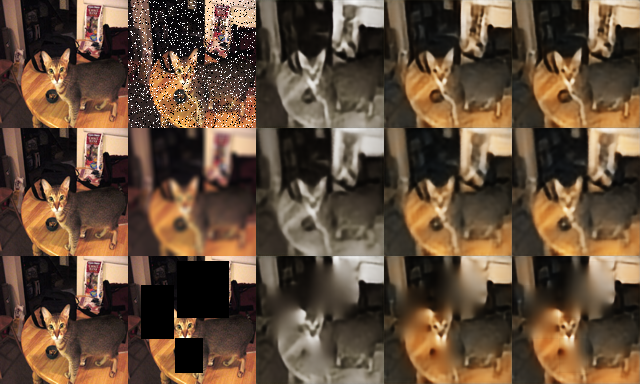

columns: original | corrupted input | universal | hard-routed | soft MoE


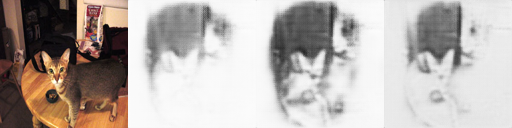

columns: photo | style 1 | style 2 | style 3 | [43.8, 28.3, 26.9] ms


In [ ]:
!pip -q install fastapi python-multipart httpx onnxruntime opencv-python-headless

import os, sys, io, base64, numpy as np
os.environ["MODEL_DIR"] = "/content/drive/MyDrive/genai_a1/checkpoints/onnx"
%cd /content/repo/backend
sys.path.insert(0, ".")
from fastapi.testclient import TestClient
from PIL import Image
from app import main

def to_png(arr):
    b = io.BytesIO(); Image.fromarray(arr).save(b, "PNG"); return b.getvalue()

def dec(url):
    return np.asarray(Image.open(io.BytesIO(base64.b64decode(url.split(",", 1)[1]))).convert("RGB"))

# a real Pets test image if possible, otherwise an FS2K photo
try:
    sys.path.insert(0, "/content/repo")
    from src.data.pets import load_pets
    imgs, idx = load_pets("test")
    a = np.asarray(imgs[0]); a = a.transpose(1, 2, 0) if a.shape[0] == 3 else a
    img = (a * 255).astype(np.uint8) if a.dtype != np.uint8 else a
except Exception as e:
    print("Pets fallback:", e)
    img = np.load("/content/data/fs2k/test_photo.npy")[0]
    img = img.transpose(1, 2, 0) if img.shape[0] == 3 else img
png = to_png(img)

with TestClient(main.app) as c:
    h = c.get("/api/health").json(); print(h["status"], h["models"])
    rows = []
    for corr in ["salt_pepper", "blur", "occlusion"]:
        d = {"corruption": corr, "severity": "high", "seed": "1"}
        u = c.post("/api/universal", files={"image": ("a.png", png, "image/png")}, data=d).json()
        k = c.post("/api/hard", files={"image": ("a.png", png, "image/png")}, data=d).json()
        s = c.post("/api/soft", files={"image": ("a.png", png, "image/png")}, data=d).json()
        print(f"{corr:12s} universal {u['psnr']} {u['inference_ms']}ms | hard -> {k['predicted']} "
              f"(p={max(k['probabilities'].values()):.3f}, {k['expert']}) {k['psnr']['restored']} dB | "
              f"soft {s['weights']} {s['psnr']['restored']} dB")
        rows.append(np.concatenate([dec(u["original"]), dec(u["input"]), dec(u["restored"]),
                                    dec(k["restored"]), dec(s["restored"])], 1))
    display(Image.fromarray(np.concatenate(rows, 0)))
    print("columns: original | corrupted input | universal | hard-routed | soft MoE")

    sk = [c.post("/api/sketch", files={"photo": ("p.png", png, "image/png")}, data={"style": str(i)}).json()
          for i in (1, 2, 3)]
    display(Image.fromarray(np.concatenate([dec(sk[0]["photo"])] + [dec(x["sketch"]) for x in sk], 1)))
    print("columns: photo | style 1 | style 2 | style 3 |", [x["inference_ms"] for x in sk], "ms")

#FRONTEND

In [20]:
import numpy as np, os, shutil
from PIL import Image
os.makedirs("/content/samples", exist_ok=True)

pets = np.load("/content/data/pets/test.npy", mmap_mode="r")
for k, i in enumerate(np.linspace(0, len(pets) - 1, 8, dtype=int)):
    Image.fromarray(np.asarray(pets[i])).save(f"/content/samples/pet_{k+1:02d}.png")

faces = np.load("/content/data/fs2k/test_photo.npy")
for k, i in enumerate(np.linspace(0, len(faces) - 1, 6, dtype=int)):
    Image.fromarray(faces[i]).save(f"/content/samples/face_{k+1:02d}.png")

print(sorted(os.listdir("/content/samples")))
shutil.make_archive("/content/samples", "zip", "/content/samples")
from google.colab import files
files.download("/content/samples.zip")

['face_01.png', 'face_02.png', 'face_03.png', 'face_04.png', 'face_05.png', 'face_06.png', 'pet_01.png', 'pet_02.png', 'pet_03.png', 'pet_04.png', 'pet_05.png', 'pet_06.png', 'pet_07.png', 'pet_08.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
!pip -q install optuna
import os, shutil, json
import optuna, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from optuna.visualization import matplotlib as ovm

SRC = "/content/drive/MyDrive/genai_a1/checkpoints/studies"
OUT = "/content/optuna_plots"; os.makedirs(OUT, exist_ok=True)
os.makedirs("/content/studies_copy", exist_ok=True)
STUDIES = ["task1_ae_v3", "task2_cls", "task2_spec_v3", "task3_moe", "task4_gan"]

summary = {}
for name in STUDIES:
    src = f"{SRC}/{name}.db"
    if not os.path.exists(src):
        print("missing:", name); continue
    shutil.copy(src, f"/content/studies_copy/{name}.db")
    st = optuna.load_study(study_name=name, storage=f"sqlite:////content/studies_copy/{name}.db")
    states = [t.state.name for t in st.trials]
    summary[name] = dict(total=len(states), complete=states.count("COMPLETE"),
                         pruned=states.count("PRUNED"), best_value=st.best_value,
                         best_params=st.best_params)
    for kind, fn in [("history", ovm.plot_optimization_history),
                     ("importance", ovm.plot_param_importances),
                     ("parallel", ovm.plot_parallel_coordinate)]:
        try:
            ax = fn(st)
            ax.figure.savefig(f"{OUT}/{name}_{kind}.png", dpi=150, bbox_inches="tight")
        except Exception as e:
            print(name, kind, "skipped:", type(e).__name__, str(e)[:100])
        plt.close("all")

json.dump(summary, open(f"{OUT}/optuna_summary.json", "w"), indent=2)
print(json.dumps(summary, indent=1))
shutil.make_archive("/content/optuna_plots", "zip", OUT)
from google.colab import files
files.download("/content/optuna_plots.zip")

/tmp/ipykernel_560/964226029.py:28: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(st)
/tmp/ipykernel_560/964226029.py:28: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(st)
/tmp/ipykernel_560/964226029.py:28: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(st)
/tmp/ipykernel_560/964226029.py:28: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(st)
/tmp/ipykernel_560/964226029.py:28: ExperimentalWarning: optuna.visualization.ma

{
 "task1_ae_v3": {
  "total": 24,
  "complete": 9,
  "pruned": 15,
  "best_value": 0.6027942359447479,
  "best_params": {
   "lr": 0.0004549902457423108,
   "batch_size": 32,
   "latent_ch": 64,
   "base": 32,
   "dropout": 0.1,
   "alpha": 0.6,
   "skip_ch": 4
  }
 },
 "task2_cls": {
  "total": 30,
  "complete": 6,
  "pruned": 24,
  "best_value": 0.9986412943148505,
  "best_params": {
   "lr": 0.0007106591851092234,
   "batch_size": 16,
   "channels": "small",
   "dropout": 0.5,
   "weight_decay": 0.00025378155082656634
  }
 },
 "task2_spec_v3": {
  "total": 12,
  "complete": 6,
  "pruned": 6,
  "best_value": 0.5999490022659302,
  "best_params": {
   "lr": 0.0009024740059313989,
   "batch_size": 16,
   "base": 32,
   "latent_ch": 48,
   "skip_ch": 8,
   "alpha": 0.6
  }
 },
 "task3_moe": {
  "total": 10,
  "complete": 10,
  "pruned": 0,
  "best_value": 0.8113611459732055,
  "best_params": {
   "lr_joint": 0.00011265466963346021,
   "T": 1.2615344229334267,
   "lam_cls": 0.01567993391

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import importlib.metadata as md
for p in ["torch","torchvision","numpy","pillow","scikit-learn","matplotlib","tqdm",
          "optuna","wandb","pytorch-msssim","onnx","onnxruntime"]:
    try: print(f"{p}=={md.version(p)}")
    except Exception as e: print(p, "NOT FOUND")

torch==2.11.0+cu130
torchvision==0.26.0+cu130
numpy==2.1.3
pillow==11.3.0
scikit-learn==1.6.1
matplotlib==3.10.0
tqdm==4.67.3
optuna==5.0.0
wandb==0.28.1
pytorch-msssim==1.0.0
onnx==1.23.1
onnxruntime==1.30.0


#DOCKER

In [31]:
%cd /content/repo
!python scripts/download_models.py
!ls -la models

/content/repo
Retrieving folder contents
Processing file 1N2Dfq56fH3sXViS6WXKIwxqERoqZJRJI onnx_consistency.json
Processing file 1J7hQlv-O6QCwTQ8ntf84rR4pmm-JufC2 task1_universal.onnx
Processing file 1Rw-_HaqMbigQ5C9PQ3AzTZmkHA58fG5a task2_classifier.onnx
Processing file 1UZnSVcodYci3Wx-etl3Fclrcq-tWHTMH task2_spec_blur.onnx
Processing file 1yQEr9zxbMPHZO5cdk9MF_p3KSDlSMe9a task2_spec_occ.onnx
Processing file 1dAe8zibQaMqakh1kUEiRipYvClHgp_5l task2_spec_salt.onnx
Processing file 1F2AyD3_WRGsthrFCkVSHGgmel-SLihR1 task3_softmoe.onnx
Processing file 1aITs0RxAHTMWISojWnGOC_IT4r1eRnyN task4_generator.onnx
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1N2Dfq56fH3sXViS6WXKIwxqERoqZJRJI
To: /content/repo/models/onnx_consistency.json
100% 2.03k/2.03k [00:00<00:00, 6.64MB/s]
Downloading...
From: https://drive.google.com/uc?id=1J7hQlv-O6QCwTQ8ntf84rR4pmm-JufC2
To: /content/repo/models/ta

#EXTRA

In [ ]:
import os, shutil
src = "/content/drive/MyDrive/genai_a1/data/pets"
dst = "/content/data/pets"
os.makedirs("/content/data", exist_ok=True)
if not os.path.exists(dst + "/trainval.npy"):
    shutil.copytree(src, dst, dirs_exist_ok=True)
print(os.listdir(dst))

[]


In [ ]:
!ls /content/drive/MyDrive/genai_a1/checkpoints/studies 2>&1

In [ ]:
!ls -la /content/drive/MyDrive/genai_a1/data/
!ls -la /content/drive/MyDrive/genai_a1/data/pets
!find /content/drive/MyDrive -maxdepth 4 -name "trainval.npy" 2>/dev/null

total 20
drwx------ 5 root root 4096 Oct  2 11:25 .
drwx------ 4 root root 4096 Oct  2 11:25 ..
drwx------ 2 root root 4096 Oct  2 11:52 fs2k
drwx------ 2 root root 4096 Oct  2 11:25 pets
drwx------ 2 root root 4096 Oct  2 11:25 raw
total 8
drwx------ 2 root root 4096 Oct  2 11:25 .
drwx------ 5 root root 4096 Oct  2 11:25 ..


In [ ]:
import os
os.chdir("/content")
base = "/content/drive/MyDrive/genai_a1/checkpoints"
!cp -r {base}/task1 {base}/task1_v1
!cp -r {base}/task2 {base}/task2_v1
!rm -f {base}/task2/spec_*.pt {base}/task2/spec_*_val_summary.json
!ls {base} {base}/task2

/content/drive/MyDrive/genai_a1/checkpoints:
studies  task1	task1_v1  task2  task2_v1

/content/drive/MyDrive/genai_a1/checkpoints/task2:
classifier.pt		     task2_cls_optuna_trials.csv
classifier_val_metrics.json  task2_spec_best.json
eval			     task2_spec_optuna_trials.csv
task2_cls_best.json


In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
base = "/content/drive/MyDrive/genai_a1"
print("folder found:", os.path.exists(base))
!ls -la {base}/checkpoints
!ls -la {base}/checkpoints/task2_v1
t = base + "/checkpoints/_write_test.txt"
open(t, "w").write("ok"); print("write ok:", os.path.exists(t)); os.remove(t)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
folder found: True
total 28
drwx------ 7 root root 4096 Oct  2 11:25 .
drwx------ 4 root root 4096 Oct  3 09:22 ..
drwx------ 2 root root 4096 Oct  2 12:26 studies
drwx------ 2 root root 4096 Oct  2 13:39 task1
drwx------ 2 root root 4096 Oct  3 08:30 task1_v1
drwx------ 2 root root 4096 Oct  2 14:47 task2
drwx------ 2 root root 4096 Oct  3 08:30 task2_v1
total 130764
drwx------ 3 root root     4096 Oct  3 08:30 .
drwx------ 7 root root     4096 Oct  2 11:25 ..
-rw------- 1 root root  1201653 Oct  3 08:30 classifier.pt
-rw------- 1 root root      795 Oct  3 08:30 classifier_val_metrics.json
drwx------ 2 root root     4096 Oct  3 08:30 eval
-rw------- 1 root root 44223883 Oct  3 08:30 spec_blur.pt
-rw------- 1 root root      992 Oct  3 08:30 spec_blur_val_summary.json
-rw------- 1 root root 44223751 Oct  3 08:30 spec_occ.pt
-rw------- 1 root root     1013 Oct 